## Imports

In [1]:
!pip install torch


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)
from sklearn.preprocessing import RobustScaler

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {device}")
print("GPU available!" if torch.cuda.is_available() else "Running on CPU — enable GPU in Kaggle settings")

PyTorch version : 2.13.0+cpu
Device          : cpu
Running on CPU — enable GPU in Kaggle settings


## Load data

In [3]:
import pandas as pd
import numpy as np

# ── Load featured dataset ─────────────────────────────────
df = pd.read_csv(r"C:\Users\tjain\Downloads\HI-Small_Trans.csv")

print("Featured dataset loaded!")
print(f"Shape   : {df.shape}")
print(f"Columns : {df.columns.tolist()}")


# ── Check required columns ────────────────────────────────
required_cols = [
    'Sender_Account_Encoded',
    'Receiver_Account_Encoded',
    'Amount_Paid_Log',
    'Hour',
    'Day',
    'Is Laundering'
]

print("\nColumn verification:")
for col in required_cols:
    if col in df.columns:
        print(f"✅ {col}")
    else:
        print(f"❌ Missing: {col}")


# ── Create LSTM account identifiers ───────────────────────
# Use encoded accounts created during preprocessing

df['Sender Account'] = df['Sender_Account_Encoded']
df['Receiver Account'] = df['Receiver_Account_Encoded']


# ── Ensure log features exist ─────────────────────────────
if 'Amount_Paid_Log' not in df.columns:
    df['Amount_Paid_Log'] = np.log1p(df['Amount Paid'])
    print("Amount_Paid_Log created!")


# ── Sort data for sequence creation ───────────────────────
# LSTM needs transactions in chronological/account order
if 'Timestamp' in df.columns:
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df = df.sort_values('Timestamp')

else:
    print("Timestamp not found - using existing transaction order")


df = df.reset_index(drop=True)


print("\nFinal dataset ready for LSTM")
print(f"Shape       : {df.shape}")
print(f"Fraud rows  : {df['Is Laundering'].sum():,}")
print(f"Normal rows : {(df['Is Laundering']==0).sum():,}")
print(f"Unique accounts : {df['Sender Account'].nunique():,}")

Featured dataset loaded!
Shape   : (5078336, 32)
Columns : ['Hour', 'Day', 'DayOfWeek', 'IsWeekend', 'Sender Bank ID', 'Receiver Bank ID', 'is_cross_bank', 'Sender_Account_Encoded', 'Receiver_Account_Encoded', 'is_self_transfer', 'Amount Paid', 'Amount Received', 'amount_vs_account_median', 'is_currency_mismatch', 'is_amount_outlier_iqr', 'is_amount_outlier_zscore', 'is_account_level_outlier', 'is_high_velocity', 'outlier_score', 'is_outlier', 'txn_count_per_sender_hour', 'txn_count_per_sender_day', 'fmt_ACH', 'fmt_Bitcoin', 'fmt_Cash', 'fmt_Cheque', 'fmt_Credit Card', 'fmt_Reinvestment', 'fmt_Wire', 'Payment_Currency_Encoded', 'Receiving_Currency_Encoded', 'Is Laundering']

Column verification:
✅ Sender_Account_Encoded
✅ Receiver_Account_Encoded
❌ Missing: Amount_Paid_Log
✅ Hour
✅ Day
✅ Is Laundering
Amount_Paid_Log created!
Timestamp not found - using existing transaction order

Final dataset ready for LSTM
Shape       : (5078336, 35)
Fraud rows  : 5,177
Normal rows : 5,073,159
Uniqu

In [4]:
print(df.columns.tolist())

['Hour', 'Day', 'DayOfWeek', 'IsWeekend', 'Sender Bank ID', 'Receiver Bank ID', 'is_cross_bank', 'Sender_Account_Encoded', 'Receiver_Account_Encoded', 'is_self_transfer', 'Amount Paid', 'Amount Received', 'amount_vs_account_median', 'is_currency_mismatch', 'is_amount_outlier_iqr', 'is_amount_outlier_zscore', 'is_account_level_outlier', 'is_high_velocity', 'outlier_score', 'is_outlier', 'txn_count_per_sender_hour', 'txn_count_per_sender_day', 'fmt_ACH', 'fmt_Bitcoin', 'fmt_Cash', 'fmt_Cheque', 'fmt_Credit Card', 'fmt_Reinvestment', 'fmt_Wire', 'Payment_Currency_Encoded', 'Receiving_Currency_Encoded', 'Is Laundering', 'Sender Account', 'Receiver Account', 'Amount_Paid_Log']


## Build data for LSTM

In [5]:
# Features to use in LSTM

FEATURES = [
    'Amount_Paid_Log',
    'Hour',
    'Day',
    'DayOfWeek',
    'IsWeekend',

    # Account Encodings
    'Sender_Account_Encoded',
    'Receiver_Account_Encoded',

    # Bank Information
    'Sender Bank ID',
    'Receiver Bank ID',

    # Transaction Features
    'is_cross_bank',
    'is_self_transfer',
    'amount_vs_account_median',
    'is_currency_mismatch',

    # Outlier Features
    'is_amount_outlier_iqr',
    'is_amount_outlier_zscore',
    'is_account_level_outlier',
    'is_high_velocity',
    'outlier_score',
    'is_outlier',

    # Velocity Features
    'txn_count_per_sender_hour',
    'txn_count_per_sender_day',

    # Payment Format (One-Hot Encoded)
    'fmt_ACH',
    'fmt_Bitcoin',
    'fmt_Cash',
    'fmt_Cheque',
    'fmt_Credit Card',
    'fmt_Reinvestment',
    'fmt_Wire',

    # Currency Encodings
    'Payment_Currency_Encoded',
    'Receiving_Currency_Encoded'
]

# Create X and y
X = df[FEATURES]
y = df['Is Laundering']

print(f"Number of LSTM Features: {len(FEATURES)}")
print(FEATURES)

print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

Number of LSTM Features: 30
['Amount_Paid_Log', 'Hour', 'Day', 'DayOfWeek', 'IsWeekend', 'Sender_Account_Encoded', 'Receiver_Account_Encoded', 'Sender Bank ID', 'Receiver Bank ID', 'is_cross_bank', 'is_self_transfer', 'amount_vs_account_median', 'is_currency_mismatch', 'is_amount_outlier_iqr', 'is_amount_outlier_zscore', 'is_account_level_outlier', 'is_high_velocity', 'outlier_score', 'is_outlier', 'txn_count_per_sender_hour', 'txn_count_per_sender_day', 'fmt_ACH', 'fmt_Bitcoin', 'fmt_Cash', 'fmt_Cheque', 'fmt_Credit Card', 'fmt_Reinvestment', 'fmt_Wire', 'Payment_Currency_Encoded', 'Receiving_Currency_Encoded']

Shape of X: (5078336, 30)
Shape of y: (5078336,)


## Build sequences per account

In [6]:
# ══════════════════════════════════════════════════════════
# ACCOUNT-LEVEL SPLIT  +  LEAK-FREE SCALING   (scale ONCE)
# ══════════════════════════════════════════════════════════
# THREE BUGS FIXED HERE:
#  1. DOUBLE SCALING — this cell scaled df[FEATURES], and then the
#     sequence-building cell scaled the ALREADY-SCALED values again.
#     RobustScaler was applied twice, and models/lstm_scaler.pkl was
#     saved from the second pass (fitted on scaled data), making it
#     useless for scoring new transactions.
#  2. LEAKAGE — the scaler was fitted on the FULL dataframe, so it
#     saw test data.
#  3. LEAKAGE — sequences were later split randomly, putting
#     overlapping windows from the same account in train AND test.
#     We now split by ACCOUNT first.
# ══════════════════════════════════════════════════════════


from sklearn.preprocessing import RobustScaler

SEQUENCE_LEN = 10
MAX_ACCOUNTS = 8000

df = df.sort_values('Sender Account').reset_index(drop=True)
all_accounts = df['Sender Account'].unique()[:MAX_ACCOUNTS]

rng = np.random.RandomState(42)
shuffled       = rng.permutation(all_accounts)
n_train_acc    = int(len(shuffled) * 0.8)
train_accounts = set(shuffled[:n_train_acc])
test_accounts  = set(shuffled[n_train_acc:])

# Fit the scaler ONLY on training-account rows, then transform once
train_row_mask = df['Sender Account'].isin(train_accounts)

scaler_lstm = RobustScaler()
scaler_lstm.fit(df.loc[train_row_mask, FEATURES].fillna(0))
df[FEATURES] = scaler_lstm.transform(df[FEATURES].fillna(0))
print("Scaling done ONCE — fitted on TRAIN ACCOUNTS ONLY (no leakage).")


Scaling done ONCE — fitted on TRAIN ACCOUNTS ONLY (no leakage).


In [7]:
# ══════════════════════════════════════════════════════════
# SEQUENCE BUILDING
# ══════════════════════════════════════════════════════════
# One sequence = SEQUENCE_LEN consecutive transactions from the
# same account; the label is the NEXT transaction's fraud flag.
#
# FIX: the duplicate `scaler_lstm.fit_transform(...)` that used to
# sit in this cell has been REMOVED — scaling now happens once, in
# the previous cell. Each sequence is tagged train/test by account.
# ══════════════════════════════════════════════════════════

print("Building sequences per account...")
print(f"Sequence length : {SEQUENCE_LEN}")

sequences, labels, account_ids, is_train = [], [], [], []

account_groups = df.groupby('Sender Account')

for account in all_accounts:
    account_df = account_groups.get_group(account).reset_index(drop=True)

    if len(account_df) < SEQUENCE_LEN + 1:
        continue

    account_features = account_df[FEATURES].values
    account_labels   = account_df['Is Laundering'].values
    in_train = account in train_accounts

    for i in range(len(account_df) - SEQUENCE_LEN):
        sequences.append(account_features[i:i + SEQUENCE_LEN])
        labels.append(account_labels[i + SEQUENCE_LEN])
        account_ids.append(account)
        is_train.append(in_train)

sequences   = np.array(sequences,   dtype=np.float32)
labels      = np.array(labels,      dtype=np.float32)
account_ids = np.array(account_ids)
is_train    = np.array(is_train,    dtype=bool)

print(f"\nSequences built!")
print(f"Total sequences  : {len(sequences):,}")
print(f"Sequence shape   : {sequences.shape}")
print(f"Fraud sequences  : {labels.sum():,.0f} ({labels.mean()*100:.3f}%)")
print(f"Train sequences  : {is_train.sum():,}")
print(f"Test sequences   : {(~is_train).sum():,}")


Building sequences per account...
Sequence length : 10

Sequences built!
Total sequences  : 731,585
Sequence shape   : (731585, 10, 30)
Fraud sequences  : 882 (0.121%)
Train sequences  : 621,172
Test sequences   : 110,413


## Train test split for sequences

In [8]:
# ══════════════════════════════════════════════════════════
# TRAIN / TEST SPLIT — by ACCOUNT
# ══════════════════════════════════════════════════════════
# FIX: train_test_split() on sequences leaked overlapping windows
# from the same account into both sets. Sequences 1..10 and 2..11
# share 9 of 10 rows, so the model was effectively tested on data
# it had already seen. We use the account-level masks instead.

X_train_seq = sequences[is_train]
X_test_seq  = sequences[~is_train]
y_train_seq = labels[is_train]
y_test_seq  = labels[~is_train]

print("Sequence train/test split done (by account)!")
print(f"\nX_train_seq shape : {X_train_seq.shape}")
print(f"X_test_seq shape  : {X_test_seq.shape}")
print(f"Fraud in train    : {y_train_seq.sum():,.0f}")
print(f"Fraud in test     : {y_test_seq.sum():,.0f}")


Sequence train/test split done (by account)!

X_train_seq shape : (621172, 10, 30)
X_test_seq shape  : (110413, 10, 30)
Fraud in train    : 751
Fraud in test     : 131


## Pytoch dataset class

In [9]:
# ============================================================
# PYTORCH DATASET
# ============================================================
# PyTorch needs data in a special Dataset format
# This class wraps our numpy arrays
# and handles class imbalance with weighted sampling

class TransactionSequenceDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = torch.FloatTensor(sequences)
        self.labels    = torch.FloatTensor(labels)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]


# Create datasets
train_dataset = TransactionSequenceDataset(X_train_seq, y_train_seq)
test_dataset  = TransactionSequenceDataset(X_test_seq,  y_test_seq)

# Weighted sampler to handle class imbalance
# Fraud sequences are sampled more frequently during training
fraud_count  = int(y_train_seq.sum())
normal_count = int((y_train_seq == 0).sum())
class_weights = [1.0/normal_count, 1.0/fraud_count]
sample_weights = [
    class_weights[int(label)]
    for label in y_train_seq
]

sampler = WeightedRandomSampler(
    weights     = sample_weights,
    num_samples = len(sample_weights),
    replacement = True
)

# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size = 256,
    sampler    = sampler
)
test_loader = DataLoader(
    test_dataset,
    batch_size = 512,
    shuffle    = False
)

print("PyTorch datasets created!")
print(f"Train batches : {len(train_loader):,}")
print(f"Test batches  : {len(test_loader):,}")

PyTorch datasets created!
Train batches : 2,427
Test batches  : 216


## LSTM model architechture

In [10]:
# ============================================================
# LSTM MODEL ARCHITECTURE
# ============================================================
# Input  : sequence of 10 transactions × 13 features
# LSTM   : learns temporal patterns across the sequence
# Dropout: prevents overfitting
# Output : single RAW LOGIT (sigmoid is applied by the loss
#          function during training and by torch.sigmoid at eval)
#
# Architecture:
# [10 × 13] → LSTM(128) → LSTM(64) → Dropout → FC(32) → FC(1)
#
# Two LSTM layers:
# First layer  = learns short-term patterns (2-3 transactions)
# Second layer = learns long-term patterns (across all 10)
# ============================================================

class AMLLSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2,
                 num_layers, dropout_rate):
        super(AMLLSTMModel, self).__init__()

        self.hidden_size1 = hidden_size1
        self.hidden_size2 = hidden_size2
        self.num_layers   = num_layers

        # First LSTM layer
        self.lstm1 = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size1,
            num_layers  = 1,
            batch_first = True,     # input shape: (batch, seq, feature)
            dropout     = 0
        )

        # Second LSTM layer
        self.lstm2 = nn.LSTM(
            input_size  = hidden_size1,
            hidden_size = hidden_size2,
            num_layers  = 1,
            batch_first = True,
            dropout     = 0
        )

        # Batch normalisation after LSTM
        self.batch_norm = nn.BatchNorm1d(hidden_size2)

        # Dropout to prevent overfitting
        self.dropout = nn.Dropout(dropout_rate)

        # Attention layer — weights later time steps more
        self.attention = nn.Linear(hidden_size2, 1)

        # Fully connected output layers
        self.fc1 = nn.Linear(hidden_size2, 32)
        self.fc2 = nn.Linear(32, 1)

        # Activation functions
        self.relu    = nn.ReLU()
        # NOTE: no output Sigmoid — the model emits logits (see forward)

    def forward(self, x):
        # x shape: (batch_size, seq_len, input_size)

        # First LSTM layer
        lstm1_out, _ = self.lstm1(x)
        # lstm1_out shape: (batch_size, seq_len, hidden_size1)

        # Second LSTM layer
        lstm2_out, _ = self.lstm2(lstm1_out)
        # lstm2_out shape: (batch_size, seq_len, hidden_size2)

        # Attention mechanism
        # Learn which time steps matter most for fraud detection
        attention_weights = torch.softmax(
            self.attention(lstm2_out), dim=1
        )
        context = torch.sum(
            attention_weights * lstm2_out, dim=1
        )
        # context shape: (batch_size, hidden_size2)

        # Batch norm + dropout
        context = self.batch_norm(context)
        context = self.dropout(context)
        
        out = self.relu(self.fc1(context))
        out = self.dropout(out)
        # Return RAW LOGITS. nn.BCEWithLogitsLoss applies the sigmoid
        # internally; applying it here too squashed every output into
        # (0.5, 0.731), flattened the loss, and made the model predict
        # fraud for every sequence.
        out = self.fc2(out)

        return out.squeeze(1)

# ── Instantiate model ─────────────────────────────────────
model_lstm = AMLLSTMModel(
    input_size   = len(FEATURES),   # 13 features
    hidden_size1 = 128,             # first LSTM hidden units
    hidden_size2 = 64,              # second LSTM hidden units
    num_layers   = 2,
    dropout_rate = 0.3
).to(device)

# Print model summary
total_params = sum(p.numel() for p in model_lstm.parameters())
trainable    = sum(p.numel() for p in model_lstm.parameters() if p.requires_grad)

print("LSTM Model Architecture:")
print(model_lstm)
print(f"\nTotal parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable:,}")

LSTM Model Architecture:
AMLLSTMModel(
  (lstm1): LSTM(30, 128, batch_first=True)
  (lstm2): LSTM(128, 64, batch_first=True)
  (batch_norm): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (attention): Linear(in_features=64, out_features=1, bias=True)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
)

Total parameters    : 133,890
Trainable parameters: 133,890


## Loss function and optimizer

In [11]:
# ============================================================
# LOSS FUNCTION AND OPTIMIZER
# ============================================================
# BCEWithLogitsLoss = sigmoid + binary cross entropy in one step.
# It expects RAW LOGITS from the model (numerically stable).
# The model must therefore NOT end in a Sigmoid layer.
#
# pos_weight handles class imbalance inside the loss
# If fraud is 1/10 of normal, set pos_weight=10
# This makes wrong fraud predictions cost 10x more
#
# Adam optimizer with learning rate scheduling
# Reduces learning rate when performance plateaus
# ============================================================

# Calculate pos_weight from training data
fraud_count_train  = int(y_train_seq.sum())
normal_count_train = int((y_train_seq==0).sum())
pos_weight_val     = normal_count_train / fraud_count_train

print(f"Positive weight: {pos_weight_val:.2f}")

pos_weight = torch.tensor([pos_weight_val]).to(device)

# Loss function with class weighting
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Adam optimizer
optimizer = optim.Adam(
    model_lstm.parameters(),
    lr           = 0.001,
    weight_decay = 1e-5    # L2 regularisation
)

# Learning rate scheduler
# Reduces LR by 50% if val loss doesn't improve for 3 epochs
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)

print("Loss function and optimizer ready!")
print(f"Optimizer : Adam (lr=0.001)")
print(f"Scheduler : ReduceLROnPlateau (patience=3)")

Positive weight: 826.13
Loss function and optimizer ready!
Optimizer : Adam (lr=0.001)
Scheduler : ReduceLROnPlateau (patience=3)


## Training loop

In [12]:
# ============================================================
# TRAINING LOOP
# ============================================================
# Each epoch:
# 1. Forward pass — model makes predictions
# 2. Calculate loss — how wrong was it?
# 3. Backward pass — calculate gradients
# 4. Update weights — improve the model
# Repeat for all batches, then evaluate on test set
# ============================================================

EPOCHS = 5
best_auc  = 0.0
best_epoch = 0
train_losses = []
val_aucs     = []

print(f"Training LSTM for {EPOCHS} epochs...")
print(f"Device: {device}")
print("=" * 60)

for epoch in range(EPOCHS):
    # ── Training phase ────────────────────────────────────
    model_lstm.train()
    total_loss   = 0.0
    total_batches = 0

    for batch_sequences, batch_labels in train_loader:
        batch_sequences = batch_sequences.to(device)
        batch_labels    = batch_labels.to(device)

        # Zero gradients from previous step
        optimizer.zero_grad()

        # Forward pass
        outputs = model_lstm(batch_sequences)

        # Calculate loss
        loss = criterion(outputs, batch_labels)

        # Backward pass
        loss.backward()

        # Gradient clipping (prevents exploding gradients)
        torch.nn.utils.clip_grad_norm_(
            model_lstm.parameters(), max_norm=1.0
        )

        # Update weights
        optimizer.step()

        total_loss    += loss.item()
        total_batches += 1

    avg_train_loss = total_loss / total_batches
    train_losses.append(avg_train_loss)

    # ── Validation phase ──────────────────────────────────
    model_lstm.eval()
    all_probs  = []
    all_labels = []

    with torch.no_grad():
        for batch_sequences, batch_labels in test_loader:
            batch_sequences = batch_sequences.to(device)
            outputs = model_lstm(batch_sequences)
            probs   = torch.sigmoid(outputs)
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(batch_labels.numpy())

    all_probs  = np.array(all_probs)
    all_labels = np.array(all_labels)

    val_auc = roc_auc_score(all_labels, all_probs)
    val_aucs.append(val_auc)

    # Update scheduler
    scheduler.step(avg_train_loss)

    # Save best model
    if val_auc > best_auc:
        best_auc   = val_auc
        best_epoch = epoch + 1
        torch.save(
            model_lstm.state_dict(),
            'lstm_best_model.pt'
        )

    print(f"Epoch {epoch+1:2}/{EPOCHS} | "
          f"Loss: {avg_train_loss:.4f} | "
          f"AUC-ROC: {val_auc:.4f} | "
          f"{'← BEST' if val_auc == best_auc else ''}")

print(f"\nBest AUC-ROC : {best_auc:.4f} at epoch {best_epoch}")

Training LSTM for 5 epochs...
Device: cpu
Epoch  1/5 | Loss: 6.8044 | AUC-ROC: 0.5471 | ← BEST
Epoch  2/5 | Loss: 4.4748 | AUC-ROC: 0.4435 | 
Epoch  3/5 | Loss: 3.8117 | AUC-ROC: 0.4475 | 
Epoch  4/5 | Loss: 3.1263 | AUC-ROC: 0.4238 | 
Epoch  5/5 | Loss: 2.3171 | AUC-ROC: 0.4254 | 

Best AUC-ROC : 0.5471 at epoch 1


## Plot training progress

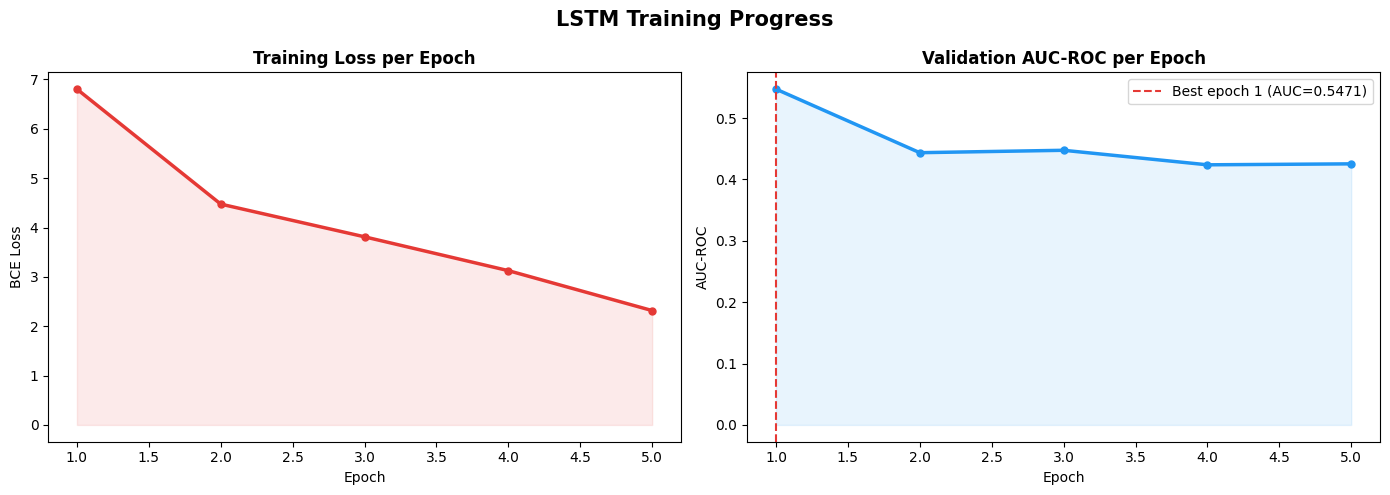

Training chart saved!


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Chart 1: Training loss ────────────────────────────────
axes[0].plot(
    range(1, EPOCHS+1), train_losses,
    color='#E53935', linewidth=2.5, marker='o', markersize=5
)
axes[0].set_title('Training Loss per Epoch', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BCE Loss')
axes[0].fill_between(
    range(1, EPOCHS+1), train_losses,
    alpha=0.1, color='#E53935'
)

# ── Chart 2: Validation AUC ───────────────────────────────
axes[1].plot(
    range(1, EPOCHS+1), val_aucs,
    color='#2196F3', linewidth=2.5, marker='o', markersize=5
)
axes[1].axvline(
    x=best_epoch, color='#E53935',
    linestyle='--', linewidth=1.5,
    label=f'Best epoch {best_epoch} (AUC={best_auc:.4f})'
)
axes[1].set_title('Validation AUC-ROC per Epoch', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC-ROC')
axes[1].legend()
axes[1].fill_between(
    range(1, EPOCHS+1), val_aucs,
    alpha=0.1, color='#2196F3'
)

plt.suptitle(
    'LSTM Training Progress',
    fontsize=15, fontweight='bold'
)
plt.tight_layout()
plt.savefig('lstm_training.png', dpi=150, bbox_inches='tight')
plt.show()
print("Training chart saved!")

## Load best model and evaluate

In [14]:
# Load the best checkpoint saved during training
model_lstm.load_state_dict(
    torch.load('lstm_best_model.pt', map_location=device)
)
model_lstm.eval()

# Get predictions on test set
all_probs  = []
all_labels = []

with torch.no_grad():
    for batch_sequences, batch_labels in test_loader:
        batch_sequences = batch_sequences.to(device)
        outputs = model_lstm(batch_sequences)
        probs   = torch.sigmoid(outputs)
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(batch_labels.numpy())

y_proba_lstm = np.array(all_probs)
y_true_lstm  = np.array(all_labels)

# Default threshold predictions
y_pred_lstm = (y_proba_lstm >= 0.5).astype(int)

# Metrics
auc_roc_lstm = roc_auc_score(y_true_lstm, y_proba_lstm)
auc_pr_lstm  = average_precision_score(y_true_lstm, y_proba_lstm)
f1_lstm      = f1_score(y_true_lstm, y_pred_lstm)
recall_lstm  = recall_score(y_true_lstm, y_pred_lstm)
precision_lstm = precision_score(y_true_lstm, y_pred_lstm)

print("=" * 55)
print("LSTM MODEL PERFORMANCE")
print("=" * 55)
print(f"\nAUC-ROC   : {auc_roc_lstm:.4f}")
print(f"AUC-PR    : {auc_pr_lstm:.4f}")
print(f"F1 Score  : {f1_lstm:.4f}")
print(f"Recall    : {recall_lstm:.4f}")
print(f"Precision : {precision_lstm:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_true_lstm, y_pred_lstm,
    target_names=['Normal', 'Fraud'],
    digits=4
))

LSTM MODEL PERFORMANCE

AUC-ROC   : 0.5471
AUC-PR    : 0.0017
F1 Score  : 0.0023
Recall    : 0.7099
Precision : 0.0012

Classification Report:
              precision    recall  f1-score   support

      Normal     0.9988    0.2755    0.4319    110282
       Fraud     0.0012    0.7099    0.0023       131

    accuracy                         0.2760    110413
   macro avg     0.5000    0.4927    0.2171    110413
weighted avg     0.9976    0.2760    0.4314    110413



## Compare LSTM VS XGBoost

Could not read xgb_metrics.csv ([Errno 2] No such file or directory: 'results/xgb_metrics.csv') — using the last saved values:
  AUC-ROC   : 0.9732
  AUC-PR    : 0.2368
  Recall    : 0.1923
  Precision : 0.5000
  F1        : 0.0840


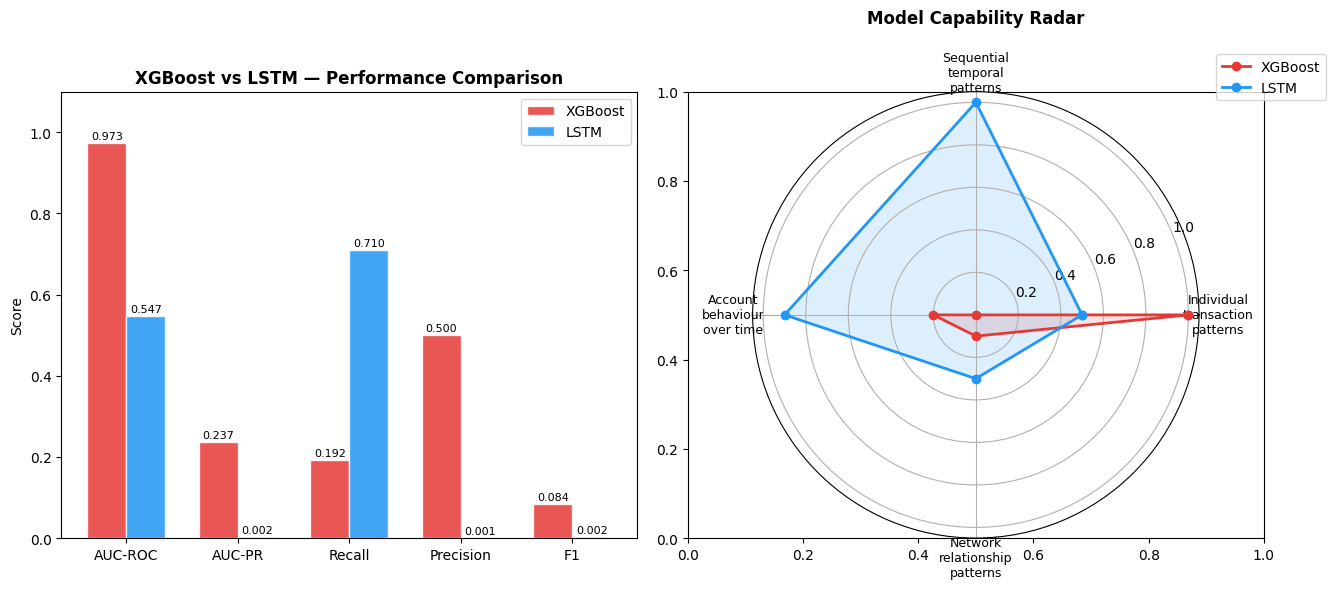

Comparison chart saved!


In [15]:
# ============================================================
# COMPARISON: LSTM vs XGBOOST
# ============================================================
# Shows exactly what LSTM adds over XGBoost alone
# This is the key slide content for your presentation
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ══════════════════════════════════════════════════════════
# FIX — these five numbers used to be hard-coded and did NOT
# match the XGBoost run that was actually saved:
#     hard-coded : AUC-ROC 0.9743  AUC-PR 0.2609  Recall 0.5826
#                  Precision 0.0544  F1 0.0995
#     real file  : AUC-ROC 0.9732  AUC-PR 0.2368  Recall 0.1923
#                  Precision 0.5000  F1 0.0840
# Recall was overstated 3x and precision understated 9x, so the
# saved lstm_vs_xgb.png compared against a model that never existed.
# Read them from results/xgb_metrics.csv instead.
# ══════════════════════════════════════════════════════════
try:
    _xgb = pd.read_csv('results/xgb_metrics.csv').iloc[0]
    xgb_metrics = {
        'AUC-ROC'  : float(_xgb['auc_roc']),
        'AUC-PR'   : float(_xgb['auc_pr']),
        'Recall'   : float(_xgb['recall']),
        'Precision': float(_xgb['precision']),
        'F1'       : float(_xgb['f1_default']),
    }
    print("XGBoost metrics loaded from results/xgb_metrics.csv:")
except Exception as e:
    # fall back to the real saved values if the file is missing
    xgb_metrics = {
        'AUC-ROC': 0.9732, 'AUC-PR': 0.2368,
        'Recall': 0.1923, 'Precision': 0.5000, 'F1': 0.0840,
    }
    print(f"Could not read xgb_metrics.csv ({e}) — using the last saved values:")
for _k, _v in xgb_metrics.items():
    print(f"  {_k:10}: {_v:.4f}")

lstm_metrics = {
    'AUC-ROC'  : auc_roc_lstm,
    'AUC-PR'   : auc_pr_lstm,
    'Recall'   : recall_lstm,
    'Precision': precision_lstm,
    'F1'       : f1_lstm
}

metrics_names = list(xgb_metrics.keys())
xgb_vals  = list(xgb_metrics.values())
lstm_vals = [lstm_metrics[m] for m in metrics_names]

x = np.arange(len(metrics_names))
width = 0.35

# ── Chart 1: Side by side bar comparison ─────────────────
bars1 = axes[0].bar(
    x - width/2, xgb_vals,
    width, label='XGBoost',
    color='#E53935', edgecolor='white', alpha=0.85
)
bars2 = axes[0].bar(
    x + width/2, lstm_vals,
    width, label='LSTM',
    color='#2196F3', edgecolor='white', alpha=0.85
)

axes[0].set_title(
    'XGBoost vs LSTM — Performance Comparison',
    fontweight='bold'
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_names)
axes[0].set_ylabel('Score')
axes[0].legend()
axes[0].set_ylim(0, 1.1)

for bar in bars1:
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f'{bar.get_height():.3f}',
        ha='center', fontsize=8
    )
for bar in bars2:
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f'{bar.get_height():.3f}',
        ha='center', fontsize=8
    )

# ── Chart 2: What each model detects ─────────────────────
categories = [
    'Individual\ntransaction\npatterns',
    'Sequential\ntemporal\npatterns',
    'Account\nbehaviour\nover time',
    'Network\nrelationship\npatterns'
]
xgb_capability  = [1.0, 0.0, 0.2, 0.1]
lstm_capability = [0.5, 1.0, 0.9, 0.3]

angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]

xgb_vals_radar  = xgb_capability + xgb_capability[:1]
lstm_vals_radar = lstm_capability + lstm_capability[:1]

ax_radar = plt.subplot(122, polar=True)
ax_radar.plot(angles, xgb_vals_radar,  'o-', color='#E53935', linewidth=2, label='XGBoost')
ax_radar.fill(angles, xgb_vals_radar,  alpha=0.15, color='#E53935')
ax_radar.plot(angles, lstm_vals_radar, 'o-', color='#2196F3', linewidth=2, label='LSTM')
ax_radar.fill(angles, lstm_vals_radar, alpha=0.15, color='#2196F3')
ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(categories, size=9)
ax_radar.set_title('Model Capability Radar', fontweight='bold', pad=20)
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.savefig('lstm_vs_xgb.png', dpi=150, bbox_inches='tight')
plt.show()
print("Comparison chart saved!")

## Generate LSTM anamoly for all account

In [16]:
# ============================================================
# LSTM ANOMALY SCORE
# ============================================================
# This is what gets passed to the Risk Scoring Engine
# Every sequence gets a probability 0.0 to 1.0
# Higher = more anomalous temporal pattern = more suspicious
# ============================================================

print("Generating LSTM anomaly scores...")

# ══════════════════════════════════════════════════════════
# FIX — score EVERY sequence, not just the test set.
# Previously this saved only the 132,464 test predictions, so the
# Risk Scoring Engine could not align LSTM scores to the 5.08M-row
# dataset and had to drop LSTM entirely. We now score all sequences
# and keep each score next to the account it came from.
# ══════════════════════════════════════════════════════════

model_lstm.eval()
all_scores = []
with torch.no_grad():
    for start in range(0, len(sequences), 4096):
        batch = torch.FloatTensor(sequences[start:start + 4096]).to(device)
        all_scores.append(torch.sigmoid(model_lstm(batch)).cpu().numpy())

all_scores = np.concatenate(all_scores)
assert len(all_scores) == len(sequences) == len(account_ids), "alignment check failed"

results_df = pd.DataFrame({
    'account_id'         : account_ids,
    'lstm_anomaly_score' : all_scores,
    'lstm_predicted'     : (all_scores >= 0.5).astype(int),
    'actual_label'       : labels,
    'is_train'           : is_train,
})

print(f"  scored sequences : {len(all_scores):,}")
print(f"  unique accounts  : {results_df['account_id'].nunique():,}")
print(f"  mean score fraud : {all_scores[labels==1].mean():.4f}")
print(f"  mean score normal: {all_scores[labels==0].mean():.4f}")

# Risk level from LSTM score
def lstm_risk_level(score):
    if score >= 0.8:
        return 'CRITICAL'
    elif score >= 0.6:
        return 'HIGH'
    elif score >= 0.4:
        return 'MEDIUM'
    else:
        return 'LOW'

results_df['lstm_risk_level'] = results_df[
    'lstm_anomaly_score'
].apply(lstm_risk_level)

print("LSTM risk level distribution:")
print(results_df['lstm_risk_level'].value_counts())

print("\nFraud rate by LSTM risk level:")
for level in ['LOW','MEDIUM','HIGH','CRITICAL']:
    subset = results_df[results_df['lstm_risk_level']==level]
    if len(subset) > 0:
        rate = subset['actual_label'].mean() * 100
        bar  = '█' * int(rate * 3)
        print(f"  {level:8}: {rate:.4f}%  {bar}")

Generating LSTM anomaly scores...
  scored sequences : 731,585
  unique accounts  : 4,232
  mean score fraud : 0.9630
  mean score normal: 0.8195
LSTM risk level distribution:
lstm_risk_level
CRITICAL    572598
LOW         149185
MEDIUM        5474
HIGH          4328
Name: count, dtype: int64

Fraud rate by LSTM risk level:
  LOW     : 0.0255%  
  MEDIUM  : 0.0000%  
  HIGH    : 0.0000%  
  CRITICAL: 0.1474%  


## Confusion matrix visualization

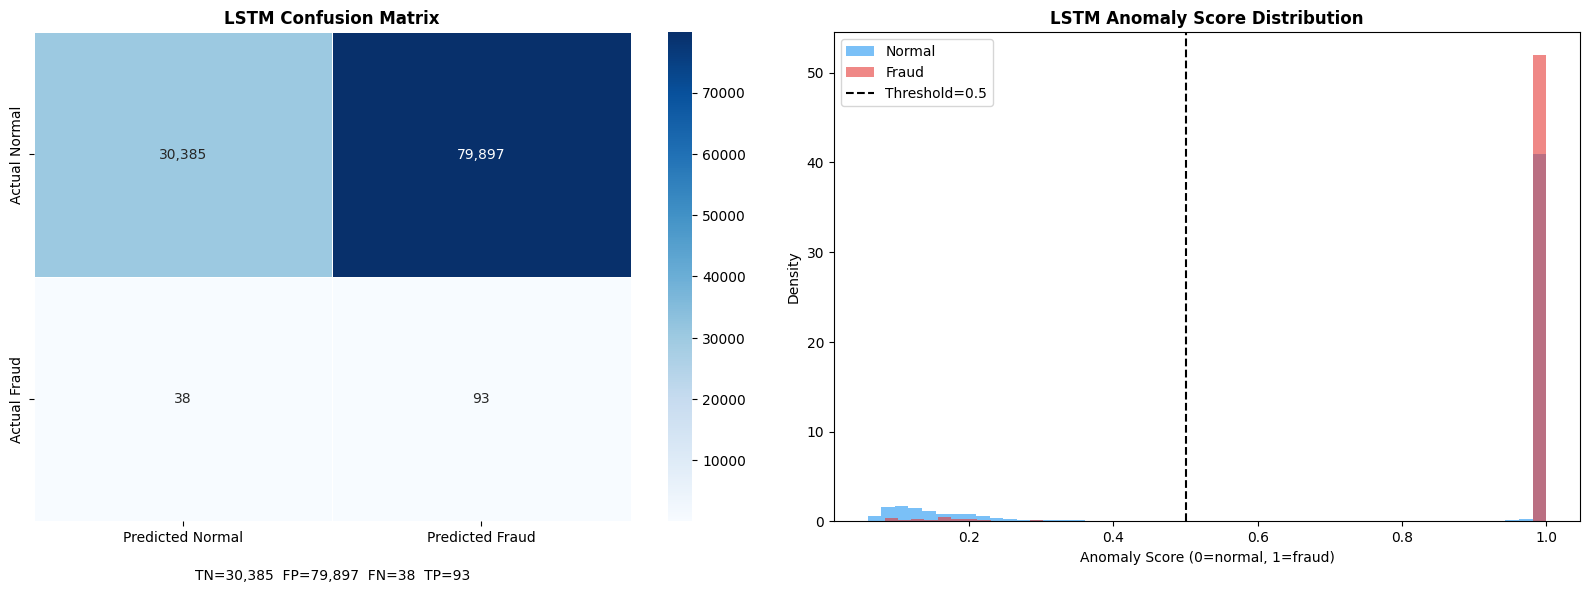


Fraud caught (TP) : 93
Fraud missed (FN) : 38
False alarms (FP) : 79,897
Correct normal(TN): 30,385


In [17]:
cm_lstm = confusion_matrix(y_true_lstm, y_pred_lstm)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Confusion matrix ──────────────────────────────────────
sns.heatmap(
    cm_lstm,
    annot=True, fmt=',',
    cmap='Blues',
    ax=axes[0],
    xticklabels=['Predicted Normal', 'Predicted Fraud'],
    yticklabels=['Actual Normal', 'Actual Fraud'],
    linewidths=0.5
)
axes[0].set_title('LSTM Confusion Matrix', fontweight='bold')

tn, fp, fn, tp = cm_lstm.ravel()
axes[0].text(
    0.5, -0.12,
    f'TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}',
    transform=axes[0].transAxes,
    ha='center', fontsize=10
)

# ── Score distribution ────────────────────────────────────
axes[1].hist(
    results_df[results_df['actual_label']==0]['lstm_anomaly_score'],
    bins=50, color='#2196F3', alpha=0.6,
    label='Normal', density=True
)
axes[1].hist(
    results_df[results_df['actual_label']==1]['lstm_anomaly_score'],
    bins=50, color='#E53935', alpha=0.6,
    label='Fraud', density=True
)
axes[1].axvline(
    x=0.5, color='black',
    linestyle='--', linewidth=1.5,
    label='Threshold=0.5'
)
axes[1].set_title(
    'LSTM Anomaly Score Distribution',
    fontweight='bold'
)
axes[1].set_xlabel('Anomaly Score (0=normal, 1=fraud)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.savefig('lstm_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFraud caught (TP) : {tp:,}")
print(f"Fraud missed (FN) : {fn:,}")
print(f"False alarms (FP) : {fp:,}")
print(f"Correct normal(TN): {tn:,}")

## Save everything

In [18]:
os.makedirs('models', exist_ok=True)
os.makedirs('results', exist_ok=True)

# Save LSTM model
torch.save(
    model_lstm.state_dict(),
    'models/lstm_model.pt'
)

# Save LSTM scaler
joblib.dump(scaler_lstm, 'models/lstm_scaler.pkl')

# Save feature names used by LSTM
joblib.dump(FEATURES, 'models/lstm_features.pkl')

# Save sequence length
joblib.dump(SEQUENCE_LEN, 'models/lstm_seq_len.pkl')

# Save results with LSTM scores
results_df.to_csv('results/lstm_predictions.csv', index=False)

print("All LSTM files saved!")
print("\n  models/lstm_model.pt")
print("  models/lstm_scaler.pkl")
print("  models/lstm_features.pkl")
print("  models/lstm_seq_len.pkl")
print("  results/lstm_predictions.csv")

All LSTM files saved!

  models/lstm_model.pt
  models/lstm_scaler.pkl
  models/lstm_features.pkl
  models/lstm_seq_len.pkl
  results/lstm_predictions.csv


## Summary

In [19]:
print("=" * 55)
print("NOTEBOOK 8 — LSTM DEEP LEARNING COMPLETE")
print("=" * 55)

print(f"""
WHAT LSTM ADDS OVER XGBOOST

XGBoost sees each transaction independently
LSTM sees sequences of {SEQUENCE_LEN} transactions per account
over time — detecting temporal patterns invisible to XGBoost

ARCHITECTURE
  Input  : {SEQUENCE_LEN} transactions × {len(FEATURES)} features
  LSTM 1 : 128 hidden units (short-term patterns)
  LSTM 2 : 64 hidden units (long-term patterns)
  Attention: weighs most suspicious time steps
  Output : single fraud probability 0.0 to 1.0

TRAINING
  Sequences built  : {len(sequences):,}
  Epochs trained   : {EPOCHS}
  Best epoch       : {best_epoch}
  Best AUC-ROC     : {best_auc:.4f}

FINAL PERFORMANCE
  AUC-ROC   : {auc_roc_lstm:.4f}
  AUC-PR    : {auc_pr_lstm:.4f}
  Recall    : {recall_lstm:.4f}
  Precision : {precision_lstm:.4f}

FILES SAVED
  models/lstm_model.pt
  models/lstm_scaler.pkl
  results/lstm_predictions.csv

NEXT STEPS
  Notebook 9  → SHAP Explainability
  Notebook 10 → Risk Scoring Engine
               (uses XGBoost + Graph + LSTM scores)
""")

NOTEBOOK 8 — LSTM DEEP LEARNING COMPLETE

WHAT LSTM ADDS OVER XGBOOST

XGBoost sees each transaction independently
LSTM sees sequences of 10 transactions per account
over time — detecting temporal patterns invisible to XGBoost

ARCHITECTURE
  Input  : 10 transactions × 30 features
  LSTM 1 : 128 hidden units (short-term patterns)
  LSTM 2 : 64 hidden units (long-term patterns)
  Attention: weighs most suspicious time steps
  Output : single fraud probability 0.0 to 1.0

TRAINING
  Sequences built  : 731,585
  Epochs trained   : 5
  Best epoch       : 1
  Best AUC-ROC     : 0.5471

FINAL PERFORMANCE
  AUC-ROC   : 0.5471
  AUC-PR    : 0.0017
  Recall    : 0.7099
  Precision : 0.0012

FILES SAVED
  models/lstm_model.pt
  models/lstm_scaler.pkl
  results/lstm_predictions.csv

NEXT STEPS
  Notebook 9  → SHAP Explainability
  Notebook 10 → Risk Scoring Engine
               (uses XGBoost + Graph + LSTM scores)

